In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import binom
from scipy.special import comb

import ast


In [6]:
dfWLO = pd.read_csv("../data/processed/soccer_binary.csv")
dfWLO.head()

,Unnamed: 0,Season,Team,Sequence,League
0,0,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",Bundesliga
1,1,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",Bundesliga
2,2,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",Bundesliga
3,3,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",Bundesliga
4,4,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",Bundesliga


In [7]:
dfWLO['Sequence'] = dfWLO['Sequence'].apply(ast.literal_eval)

In [8]:
dfWLO['League'] = dfWLO['League'].replace("E0", "Premier_League")
dfWLO['League'] = dfWLO['League'].replace("D1", "Bundesliga")
dfWLO['League'] = dfWLO['League'].replace("SP1", "La_Liga")

In [9]:
dfWLO['Sequence'].str.len()

0       28
1       28
2       31
3       24
4       29
        ..
1433    31
1434    25
1435    34
1436    25
1437    28
Name: Sequence, Length: 1438, dtype: int64

In [10]:
dfWLO['Total_Games'] = dfWLO['Sequence'].str.len()
dfWLO

,Unnamed: 0,Season,Team,Sequence,League,Total_Games
0,0,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",Bundesliga,28
1,1,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",Bundesliga,28
2,2,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",Bundesliga,31
3,3,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",Bundesliga,24
4,4,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",Bundesliga,29
...,...,...,...,...,...,...
1433,1433,2024,Sociedad,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",La_Liga,31
1434,1434,2024,Valencia,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, ...",La_Liga,25
1435,1435,2024,Valladolid,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",La_Liga,34
1436,1436,2024,Vallecano,"[1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",La_Liga,25


In [11]:
dfWLO['Wins'] = dfWLO['Sequence'].apply(sum)
dfWLO

,Unnamed: 0,Season,Team,Sequence,League,Total_Games,Wins
0,0,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",Bundesliga,28,19
1,1,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",Bundesliga,28,7
2,2,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",Bundesliga,31,12
3,3,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",Bundesliga,24,16
4,4,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",Bundesliga,29,10
...,...,...,...,...,...,...,...
1433,1433,2024,Sociedad,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",La_Liga,31,13
1434,1434,2024,Valencia,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, ...",La_Liga,25,11
1435,1435,2024,Valladolid,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",La_Liga,34,4
1436,1436,2024,Vallecano,"[1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",La_Liga,25,13


In [12]:
dfWLO['Lower_Tail'] = binom.cdf(dfWLO['Wins'], dfWLO['Total_Games'], 0.5)
dfWLO['Upper_Tail'] = 1 -binom.cdf(dfWLO['Wins'], dfWLO['Total_Games'], 0.5) + comb(dfWLO['Total_Games'], dfWLO['Wins']) / (2 ** dfWLO['Total_Games'])
dfWLO['WOAT_Score'] = 1/dfWLO['Lower_Tail']
dfWLO['GOAT_Score'] = 1/dfWLO['Upper_Tail']

In [13]:
dfWLO

,Unnamed: 0,Season,Team,Sequence,League,Total_Games,Wins,Lower_Tail,Upper_Tail,WOAT_Score,GOAT_Score
0,0,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",Bundesliga,28,19,0.982151,0.043579,1.018173,22.946687
1,1,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",Bundesliga,28,7,0.006270,0.998140,159.477534,1.001863
2,2,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",Bundesliga,31,12,0.140521,0.925194,7.116386,1.080855
3,3,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",Bundesliga,24,16,0.968043,0.075795,1.033012,13.193514
4,4,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",Bundesliga,29,10,0.068023,0.969286,14.700916,1.031687
...,...,...,...,...,...,...,...,...,...,...,...
1433,1433,2024,Sociedad,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",La_Liga,31,13,0.236565,0.859479,4.227171,1.163495
1434,1434,2024,Valencia,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, ...",La_Liga,25,11,0.345019,0.787822,2.898391,1.269322
1435,1435,2024,Valladolid,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",La_Liga,34,4,0.000003,1.000000,324417.803157,1.000000
1436,1436,2024,Vallecano,"[1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",La_Liga,25,13,0.654981,0.500000,1.526762,2.000000


In [14]:
max = dfWLO['GOAT_Score'].max()
dfWLO[dfWLO['GOAT_Score']==max]

,Unnamed: 0,Season,Team,Sequence,League,Total_Games,Wins,Lower_Tail,Upper_Tail,WOAT_Score,GOAT_Score
424,424,2023,Leverkusen,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",Bundesliga,28,28,1.0,3.725290e-09,1.0,268435456.0


In [15]:
maxW = dfWLO['WOAT_Score'].max()
dfWLO[dfWLO['WOAT_Score']==maxW]

,Unnamed: 0,Season,Team,Sequence,League,Total_Games,Wins,Lower_Tail,Upper_Tail,WOAT_Score,GOAT_Score
597,597,2007,Derby,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",Premier_League,30,1,2.887100e-08,1.0,3.463683e+07,1.0


In [16]:
#Top 10 GOAT Scores

dfWLO.nlargest(10, "GOAT_Score")[["Team", "Season", "League", "GOAT_Score"]]


,Team,Season,League,GOAT_Score
424,Leverkusen,2023,Bundesliga,2.684355e+08
1118,Barcelona,2009,La_Liga,1.301505e+08
822,Liverpool,2018,Premier_League,6.710886e+07
217,Bayern Munich,2012,Bundesliga,3.463683e+07
1412,Real Madrid,2023,La_Liga,3.463683e+07
801,Man City,2017,Premier_League,2.882528e+07
1166,Real Madrid,2011,La_Liga,2.882528e+07
1177,Barcelona,2012,La_Liga,2.882528e+07
840,Liverpool,2019,Premier_League,1.789570e+07
1278,Barcelona,2017,La_Liga,1.789570e+07


In [17]:
#Top 10 WOAT Scores

dfWLO.nlargest(10, "WOAT_Score")[["Team", "Season", "League", "WOAT_Score"]]

,Team,Season,League,WOAT_Score
597,Derby,2007,Premier_League,3.463683e+07
951,Southampton,2024,Premier_League,8.119031e+06
566,Sunderland,2005,Premier_League,7.824681e+05
820,Huddersfield,2018,Premier_League,4.301850e+05
930,Sheffield United,2023,Premier_League,4.301850e+05
1435,Valladolid,2024,La_Liga,3.244178e+05
752,Aston Villa,2015,Premier_League,2.372386e+05
507,Sunderland,2002,Premier_League,5.890456e+04
373,Schalke 04,2020,Bundesliga,4.062280e+04
1220,Cordoba,2014,La_Liga,4.062280e+04


In [18]:
dfWLO['log_GOAT'] = np.log(dfWLO['GOAT_Score'])
dfWLO['log_WOAT'] = np.log(dfWLO['WOAT_Score'])



In [19]:
dfWLO

,Unnamed: 0,Season,Team,Sequence,League,Total_Games,Wins,Lower_Tail,Upper_Tail,WOAT_Score,GOAT_Score,log_GOAT,log_WOAT
0,0,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",Bundesliga,28,19,0.982151,0.043579,1.018173,22.946687,3.133174e+00,0.018010
1,1,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",Bundesliga,28,7,0.006270,0.998140,159.477534,1.001863,1.861314e-03,5.071903
2,2,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",Bundesliga,31,12,0.140521,0.925194,7.116386,1.080855,7.775226e-02,1.962400
3,3,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",Bundesliga,24,16,0.968043,0.075795,1.033012,13.193514,2.579725e+00,0.032479
4,4,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",Bundesliga,29,10,0.068023,0.969286,14.700916,1.031687,3.119574e-02,2.687910
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1433,1433,2024,Sociedad,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",La_Liga,31,13,0.236565,0.859479,4.227171,1.163495,1.514286e-01,1.441533
1434,1434,2024,Valencia,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, ...",La_Liga,25,11,0.345019,0.787822,2.898391,1.269322,2.384832e-01,1.064156
1435,1435,2024,Valladolid,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",La_Liga,34,4,0.000003,1.000000,324417.803157,1.000000,3.830065e-07,12.689787
1436,1436,2024,Vallecano,"[1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",La_Liga,25,13,0.654981,0.500000,1.526762,2.000000,6.931472e-01,0.423149


In [20]:
top10_GOAT = dfWLO.nlargest(10, "GOAT_Score")[["Team", "Season", "League", "GOAT_Score", "log_GOAT"]]
top10_GOAT

,Team,Season,League,GOAT_Score,log_GOAT
424,Leverkusen,2023,Bundesliga,2.684355e+08,19.408121
1118,Barcelona,2009,La_Liga,1.301505e+08,18.684202
822,Liverpool,2018,Premier_League,6.710886e+07,18.021827
217,Bayern Munich,2012,Bundesliga,3.463683e+07,17.360428
1412,Real Madrid,2023,La_Liga,3.463683e+07,17.360428
801,Man City,2017,Premier_League,2.882528e+07,17.176763
1166,Real Madrid,2011,La_Liga,2.882528e+07,17.176763
1177,Barcelona,2012,La_Liga,2.882528e+07,17.176763
840,Liverpool,2019,Premier_League,1.789570e+07,16.700071
1278,Barcelona,2017,La_Liga,1.789570e+07,16.700071


In [21]:
top10_GOAT['Team_Name'] = top10_GOAT['Season'].astype(str) + ' ' + top10_GOAT['Team']
top10_GOAT

,Team,Season,League,GOAT_Score,log_GOAT,Team_Name
424,Leverkusen,2023,Bundesliga,2.684355e+08,19.408121,2023 Leverkusen
1118,Barcelona,2009,La_Liga,1.301505e+08,18.684202,2009 Barcelona
822,Liverpool,2018,Premier_League,6.710886e+07,18.021827,2018 Liverpool
217,Bayern Munich,2012,Bundesliga,3.463683e+07,17.360428,2012 Bayern Munich
1412,Real Madrid,2023,La_Liga,3.463683e+07,17.360428,2023 Real Madrid
801,Man City,2017,Premier_League,2.882528e+07,17.176763,2017 Man City
1166,Real Madrid,2011,La_Liga,2.882528e+07,17.176763,2011 Real Madrid
1177,Barcelona,2012,La_Liga,2.882528e+07,17.176763,2012 Barcelona
840,Liverpool,2019,Premier_League,1.789570e+07,16.700071,2019 Liverpool
1278,Barcelona,2017,La_Liga,1.789570e+07,16.700071,2017 Barcelona


## Bar chart of top 10 most impressive season/team pairs

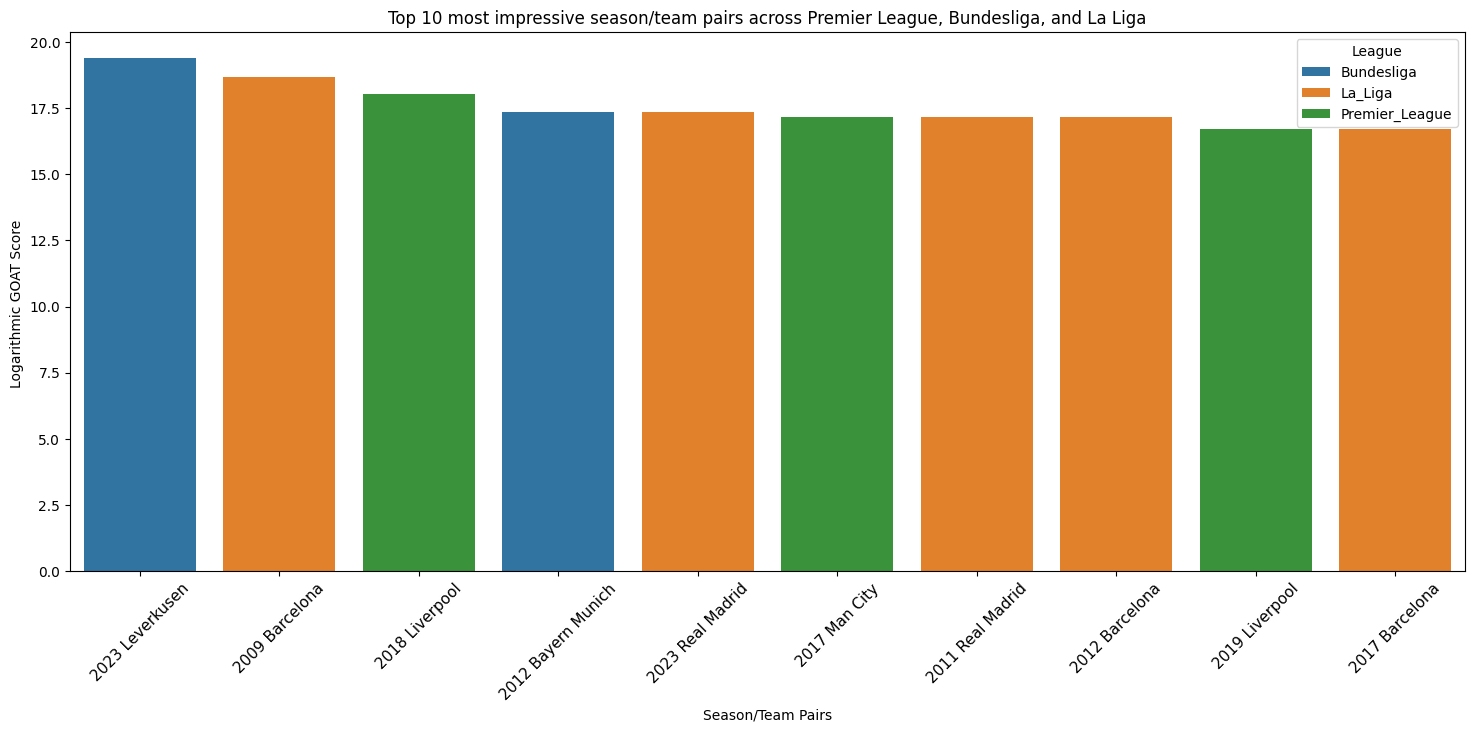

In [22]:
plt.figure(figsize=(18,7))

sns.barplot(x=top10_GOAT['Team_Name'], y = top10_GOAT['log_GOAT'], palette = 'tab10', hue = top10_GOAT['League'])
plt.title('Top 10 most impressive season/team pairs across Premier League, Bundesliga, and La Liga')
plt.xlabel('Season/Team Pairs')
plt.ylabel('Logarithmic GOAT Score ')
plt.xticks(rotation=45, fontsize=11)
plt.show()

## Histogram for Premier League GOAT Scores

In [23]:
premier_league_df = dfWLO[dfWLO['League']=='Premier_League']
premier_league_goat = premier_league_df[['Season', 'Team', 'League', 'GOAT_Score', 'log_GOAT']]
premier_league_goat

,Season,Team,League,GOAT_Score,log_GOAT
451,2000,Arsenal,Premier_League,56.025331,4.025804e+00
452,2000,Aston Villa,Premier_League,2.951422,1.082287e+00
453,2000,Bradford,Premier_League,1.000155,1.553865e-04
454,2000,Charlton,Premier_League,1.739969,5.538671e-01
455,2000,Chelsea,Premier_League,5.798304,1.757565e+00
...,...,...,...,...,...
950,2024,Nottm Forest,Premier_League,7.494968,2.014232e+00
951,2024,Southampton,Premier_League,1.000000,7.683411e-09
952,2024,Tottenham,Premier_League,1.017854,1.769668e-02
953,2024,West Ham,Premier_League,1.101888,9.702499e-02


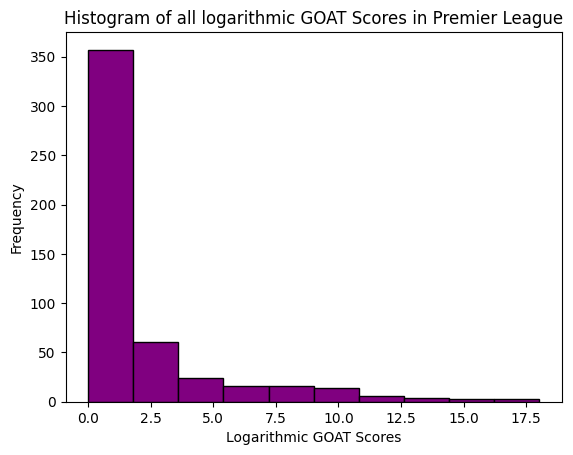

In [24]:
plt.hist(premier_league_goat['log_GOAT'], color='purple', edgecolor='black') 
plt.title('Histogram of all logarithmic GOAT Scores in Premier League')
plt.xlabel('Logarithmic GOAT Scores')
plt.ylabel('Frequency')
plt.show()

## Histogram for all Bundesliga GOAT Scores

In [25]:
bundesliga_df = dfWLO[dfWLO['League']=='Bundesliga']
bundesliga_goat = bundesliga_df[['Season', 'Team', 'League', 'GOAT_Score', 'log_GOAT']]
bundesliga_goat

,Season,Team,League,GOAT_Score,log_GOAT
0,2000,Bayern Munich,Bundesliga,22.946687,3.133174
1,2000,Bochum,Bundesliga,1.001863,0.001861
2,2000,Cottbus,Bundesliga,1.080855,0.077752
3,2000,Dortmund,Bundesliga,13.193514,2.579725
4,2000,Ein Frankfurt,Bundesliga,1.031687,0.031196
...,...,...,...,...,...
446,2024,St Pauli,Bundesliga,1.014692,0.014585
447,2024,Stuttgart,Bundesliga,2.366811,0.861543
448,2024,Union Berlin,Bundesliga,1.253819,0.226194
449,2024,Werder Bremen,Bundesliga,2.898391,1.064156


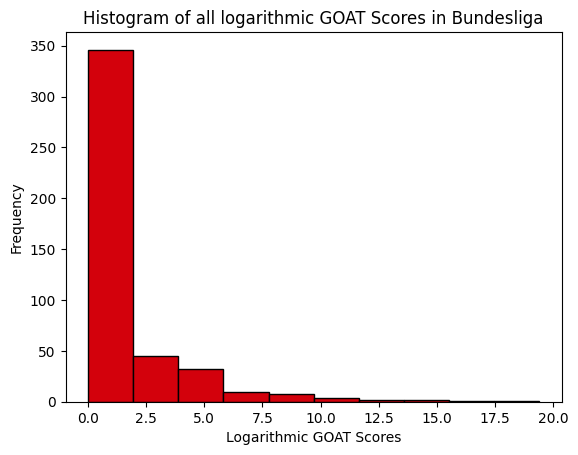

In [26]:
plt.hist(bundesliga_goat['log_GOAT'], color='#D3010C', edgecolor='black') 
plt.title('Histogram of all logarithmic GOAT Scores in Bundesliga')
plt.xlabel('Logarithmic GOAT Scores')
plt.ylabel('Frequency')
plt.show()

## Histogram for all La Liga GOAT Scores

In [27]:
la_liga_df = dfWLO[dfWLO['League']=='La_Liga']
la_liga_goat = la_liga_df[['Season', 'Team', 'League', 'GOAT_Score', 'log_GOAT']]
la_liga_goat

,Season,Team,League,GOAT_Score,log_GOAT
955,2000,Alaves,La_Liga,1.309869,2.699271e-01
956,2000,Ath Bilbao,La_Liga,1.101888,9.702499e-02
957,2000,Barcelona,La_Liga,11.859755,2.473151e+00
958,2000,Celta,La_Liga,4.524187,1.509438e+00
959,2000,Espanol,La_Liga,1.413093,3.457807e-01
...,...,...,...,...,...
1433,2024,Sociedad,La_Liga,1.163495,1.514286e-01
1434,2024,Valencia,La_Liga,1.269322,2.384832e-01
1435,2024,Valladolid,La_Liga,1.000000,3.830065e-07
1436,2024,Vallecano,La_Liga,2.000000,6.931472e-01


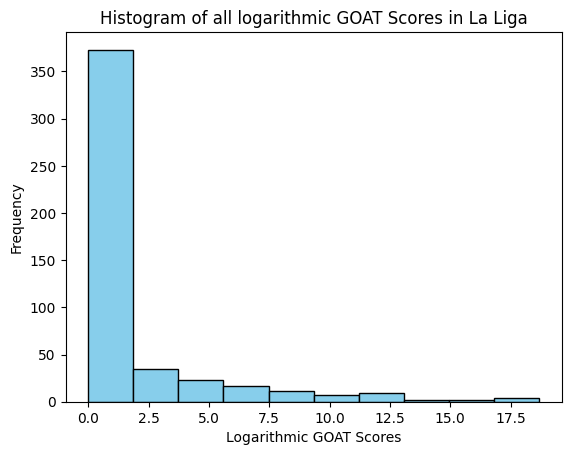

In [28]:
plt.hist(la_liga_goat['log_GOAT'], color='skyblue', edgecolor='black') 
plt.title('Histogram of all logarithmic GOAT Scores in La Liga')
plt.xlabel('Logarithmic GOAT Scores')
plt.ylabel('Frequency')
plt.show()